```text
First PD experiments
├── Business Problem
├── Model Development
│   ├── Loading
│   ├── Pre-processing
│   └── Modelling
└── Business Impact
```

# First experiments 

## Business problem

The analysis presented here represents the first iteration of the framework. Here, a model is built that predicts default risk, over a 12-month horizon, at the time of loan application for Estonia (EE). Subsequent notebooks extend the workflow with calibration, threshold optimisation, expected loss estimation, and capital analysis.

After excluding variables unavailable at application time, identifiers, leakage variables and features with no modelling value, 39 predictors remain. Missing values are handled using statistics computed on the training set, categorical variables are encoded and numerical variables are standardised for Logistic Regression.

Checking the number of observations and the default rate per year: I choose **2016-2020** as a time-period for the analysis, with **2016-2018** as a training period and **2019-2020** as a testing period. The analysis period counts higher number of loans as compared to the earlier years consisting a quite stable period. Furthermore, the default rate decreased from **19.3%** in the training period to **14.8%** in the testing period, indicating a moderate shift in portfolio risk.

Logistic Regression and Gradient Boosting are evaluated using identical training and testing periods. Logistic Regression serves as a transparent benchmark commonly used in credit risk, while Gradient Boosting captures non-linear relationships and feature interactions. Reduced models using the 20 most important variables identified by Gradient Boosting are also evaluated. Although Gradient Boosting retains slightly higher predictive performance, the Logistic Regression model with 20 variables is selected for subsequent analyses because it offers greater interpretability, stability and ease of monitoring.Performance is assessed using AUC and Gini (Table: Performance).

|        | LR (39) | GB (39) | LR (20) | GB (20) |
|--------|--------:|--------:|--------:|--------:|
| Nr of features | 39 | 39 | 20 | 20 |
| TRAIN AUC | 0,668 | 0,684 | 0,653 | 0,683 |
| TRAIN Gini | 0,335 | 0,369 | 0,306 | 0,367 |
| TEST AUC | 0,671 | 0,670 | 0,652 | 0,669 |
| TEST Gini | 0,341 | 0,340 | 0,304 | 0,337 |
| ΔGini | 0,006 | 0,029 | 0,003 | 0,029 |
<div align="center">
<figcaption>Table: Performance</figcaption>
</div>

The AUC values of both models are above 0,5 therefore both models discriminate good/bad borrowers relatively good and the Gini values are positive therefore the higher the model score the higher the number of predicted defaults is. For a consumer loan business the above AUC, Gini values are typical and acceptable for model performance. In addition the ΔGinis (difference between train Gini and test Gini) are low (<0,05) indicating generalization (no overfitting). In this configuration (using all 39 features), both models show similar performance (0,34 in test set). The fact that the GB model does not significantly outperform LR in the test set, suggests that the predictive signal in the dataset is mostly linear, therefore there is no predictive gain with modelling complexity.

The two most influential variables, based on the chosen model (LR-20), are **NewCreditCustomer** and **CreditScoreEeMini**, with positive and negative relationships to default respectively. Both variables are highly statistically significant.

Looking at the calibration plot on the test period (Figure: Calibration), we see the observed default rate increasing consistently across PD bins, indicating good ranking ability of the model, although the predicted probabilities are generally higher than the observed default rates, suggesting the model slightly overestimates risk while remaining conservative.

<div align="center">
<img src="../figures/cali_image_after_calibration.png" width="360" height="300">
</div>
<div align="center">
<figcaption>Figure: Calibration</figcaption>
</div>

Regarding the PD threshold investigation (Table: Thresholds), low PD cutoffs improve portfolio quality (default rate) but reduce approval rate. Using a **0,20** cut-off approves **81%** of loans with a default rate **12%** slightly lower than the 2019-2020 baseline default rate **14.8%**.

|Threshold |Approval       |Default       |
|----------|---------------|--------------|
|0,05	   |1,52 %	       |3,25 %|
|0,07	   |6,78 %	       |5,26 %|
|0,10	   |23,11 %	       |7,15 %|
|0,15	   |57,99 %	       |10,09 %|
|0,20	   |81,27 %	       |12,23 %|
|0,30	   |96,36 %	       |14,15 %|
<div align="center">
<figcaption>Table: Thresholds</figcaption>
</div>

## Model development

### Loading

#### Import & Setup

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.calibration import intercept_recalibration
from src.decisioning import my_impact, show_approval_vs_default_on_thresholds
from src.feature_engineering import create_target_def12, SpecialMappings
from src.metrics import my_metrics
from src.plots import default_capture_curve, my_calibration, my_dr_plot, variable_vs_dr
from src.preprocessing import my_input_load, my_time_split, ReplaceMinusOne 
from src.validation import missing_summary

# ML modules

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import xgboost

#### Data

In [3]:
# load input file

columns_to_use = [
    "NewCreditCustomer",
    "LoanApplicationStartedDate",
    "LoanDate",
    "FirstPaymentDate",
    "ApplicationSignedHour",
    "ApplicationSignedWeekday",
    "VerificationType",
    "LanguageCode",
    "Age",
    "Gender",
    "AppliedAmount",
    "Amount",
    #"Interest",
    "LoanDuration",
    "MonthlyPayment",
    "UseOfLoan",
    "Education",
    "MaritalStatus",
    "NrOfDependants",
    "EmploymentStatus",
    "EmploymentDurationCurrentEmployer",
    "WorkExperience",
    "OccupationArea",
    "HomeOwnershipType",
    "IncomeFromPrincipalEmployer",
    "IncomeFromPension",
    "IncomeFromFamilyAllowance",
    "IncomeFromSocialWelfare",
    "IncomeFromLeavePay",
    "IncomeFromChildSupport",
    "IncomeOther",
    "IncomeTotal",
    "ExistingLiabilities",
    "LiabilitiesTotal",
    "RefinanceLiabilities",
    "DebtToIncome",
    "FreeCash",
    "MonthlyPaymentDay",
    "DefaultDate",
    "CreditScoreEsMicroL",
    "CreditScoreEeMini",
    "NoOfPreviousLoansBeforeLoan",
    "AmountOfPreviousLoansBeforeLoan",
    "PreviousRepaymentsBeforeLoan",
    "PreviousEarlyRepaymentsBefoleLoan",
    "PreviousEarlyRepaymentsCountBeforeLoan",
    "Country"
]

full_dataset = my_input_load(2009, 2023, columns_to_use=columns_to_use)

In [4]:
# REPLACE MISSING VALUES (-1) WITH NAN

replacer = ReplaceMinusOne(verbose=True)
full_dataset = replacer.fit_transform(full_dataset)

Education: replacing 574 values of -1 with NaN
EmploymentStatus: replacing 140,171 values of -1 with NaN
FreeCash: replacing 1 values of -1 with NaN
HomeOwnershipType: replacing 2 values of -1 with NaN
MaritalStatus: replacing 140,171 values of -1 with NaN
OccupationArea: replacing 140,174 values of -1 with NaN
UseOfLoan: replacing 140,171 values of -1 with NaN


#### Target variable

In [5]:
# CREATE TARGET VARIABLE

full_dataset, dr_summary = create_target_def12(full_dataset)

LoanDate range:     2009-02-28 00:00:00 2023-10-14 00:00:00
+12 months:         2010-02-28 00:00:00 2024-10-14 00:00:00
DefaultDate range:  2009-06-16 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2009,665,181,0.272180
2010,1157,275,0.237684
2011,451,62,0.137472
2012,457,33,0.072210
2013,2286,233,0.101925
2014,4145,553,0.133414
2015,3432,494,0.143939
2016,6023,1282,0.212851
2017,11109,2447,0.220272
2018,16946,2865,0.169066


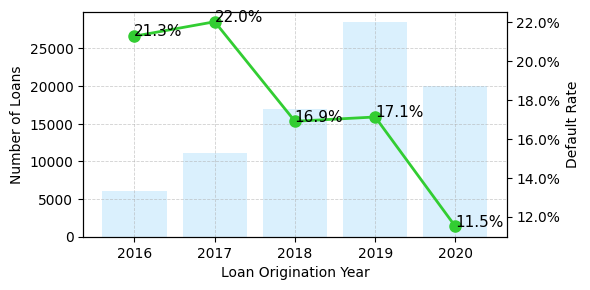

In [6]:
# PLOT TARGET VARIABLE

my_dr_plot(dr_summary, 2016, 2020)


### Pre-processing

#### split

In [7]:
# TRAIN/TEST SPLIT

windows = {"train": (2016, 2018), "test":  (2019, 2020)}

splits = my_time_split(full_dataset, "LoanYear", windows)

X_trai = splits["train"]["X"]
y_trai = splits["train"]["y"]
X_test = splits["test"]["X"]
y_test = splits["test"]["y"]


SPLIT SUMMARY

TRAIN
Years        : 2016 - 2018
Shape (X, y) : (34078, 39), (34078,)

LoanYear distribution
LoanYear
2016     6023
2017    11109
2018    16946
Name: count, dtype: int64

Default rate : 0.1935
------------------------------------------------------------

TEST
Years        : 2019 - 2020
Shape (X, y) : (48446, 39), (48446,)

LoanYear distribution
LoanYear
2019    28487
2020    19959
Name: count, dtype: int64

Default rate : 0.1481
------------------------------------------------------------


#### map categorical variables (manual)

In [8]:
# DEFINE PURE CATEGORICAL VARIABLES

categorical_variables = [
    "Education",         # 1,2,3,4,5
    "EmploymentStatus",  # 1,2,3,4,5,6
    "Gender",            # 0,1,2
    "HomeOwnershipType", # 0-10
    "LanguageCode",      # 1,2,3,4,5,6,9
    "MaritalStatus",     # 1-5
    "NewCreditCustomer", # 0,1
    "OccupationArea",    # 1-19
    "UseOfLoan",         # 0-8
    "VerificationType"   # 0-4
]

for col in categorical_variables:
    X_trai[col] = X_trai[col].astype("category")
    X_test[col] = X_test[col].astype("category")

In [9]:
# CONVERT STRING TO NUMERICAL: EmploymentDurationCurrentEmployer

var = "EmploymentDurationCurrentEmployer"
print(X_trai[var].value_counts(dropna=False))
# map on train
mapping = {
    "TrialPeriod": 0,
    "UpTo1Year": 1,
    "UpTo2Years": 2,
    "UpTo3Years": 3,
    "UpTo4Years": 4,
    "UpTo5Years": 5,
    "MoreThan5Years": 6,
    "Retiree": 7,
    "Other": np.nan
}
# apply
X_trai[var] = X_trai[var].map(mapping)
X_test[var] = X_test[var].map(mapping)
# check
print(X_trai[var].value_counts(dropna=False))

# CONVERT STRING TO NUMERICAL: WorkExperience 

var = "WorkExperience"
print(X_trai[var].value_counts(dropna=False))
# map on train
mapping = {
    "LessThan2Years": 0,
    "2To5Years": 2,
    "5To10Years": 5,
    "10To15Years": 10,
    "15To25Years": 15,
    "MoreThan25Years": 25
}
# apply
X_trai[var] = X_trai[var].map(mapping)
X_test[var] = X_test[var].map(mapping)
# check
print(X_trai[var].value_counts(dropna=False))

# CONVERT BOOL TO NUMERICAL: NewCreditCustomer

var = "NewCreditCustomer"
print(X_trai[var].value_counts(dropna=False))
# apply
X_trai[var] = X_trai[var].astype("int64")
X_test[var] = X_test[var].astype("int64")
# check
print(X_trai[var].value_counts(dropna=False))

EmploymentDurationCurrentEmployer
MoreThan5Years    11913
UpTo5Years         8380
UpTo1Year          6742
UpTo2Years         2257
UpTo3Years         1891
UpTo4Years         1179
Retiree             733
Other               635
TrialPeriod         347
NaN                   1
Name: count, dtype: int64
EmploymentDurationCurrentEmployer
6.0    11913
5.0     8380
1.0     6742
2.0     2257
3.0     1891
4.0     1179
7.0      733
NaN      636
0.0      347
Name: count, dtype: int64
WorkExperience
NaN                24269
5To10Years          2279
15To25Years         1999
10To15Years         1827
2To5Years           1590
MoreThan25Years     1570
LessThan2Years       544
Name: count, dtype: int64
WorkExperience
NaN     24269
5.0      2279
15.0     1999
10.0     1827
2.0      1590
25.0     1570
0.0       544
Name: count, dtype: int64
NewCreditCustomer
False    20825
True     13253
Name: count, dtype: int64
NewCreditCustomer
0    20825
1    13253
Name: count, dtype: int64


In [10]:
# align categories of test with categories of train
# if new categories appear -> NaN

cat_cols = X_trai.select_dtypes(include=["category"]).columns
for col in cat_cols:
    X_test[col] = pd.Categorical(
        X_test[col],
        categories=X_trai[col].cat.categories
    )

/var/folders/lw/lxw4ft892556gpxf0n3shwd40000gn/T/ipykernel_24824/1581236471.py:6: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test[col] = pd.Categorical(


In [11]:
# check alignment train/test

print(set(X_trai.columns) == set(X_test.columns)) # should be true

dtype_check = pd.DataFrame({
    "trai_dtype": X_trai.dtypes,
    "test_dtype": X_test.dtypes
})
dtype_check[dtype_check["trai_dtype"] != dtype_check["test_dtype"]]

print((X_trai.columns == X_test.columns).all()) # should be true

True
True


#### missing values

In [12]:
# MISSING VALUES

# missing summary before
#print(' ')
#print('missing summary before:')
#print(missing_summary(X_trai))

# separate nums/cats
cat_cols = X_trai.select_dtypes(include=["category"]).columns
num_cols = X_trai.select_dtypes(include=["int64", "float64"]).columns

# substitution values for numerical variables: median in training set
median_vals = X_trai[num_cols].median()
print('SUBSTITUTION VALUES FOR NUMS: ')
print(median_vals)

# substitution values for categorical variables: most common in training set
common_vals = X_trai[cat_cols].mode().iloc[0]
print('SUBSTITUTION VALUES FOR CATS: ')
print(common_vals)

# replace NaNs in numerical variables
X_trai[num_cols] = X_trai[num_cols].fillna(median_vals)
X_test[num_cols] = X_test[num_cols].fillna(median_vals)

# replace NaNs in categorical variables
X_trai[cat_cols] = X_trai[cat_cols].fillna(common_vals)
X_test[cat_cols] = X_test[cat_cols].fillna(common_vals)

# missing summary after
#print(' ')
#print('missing summary after:')
#print(missing_summary(X_trai))

SUBSTITUTION VALUES FOR NUMS: 
Age                                         38.000
Amount                                    1590.000
AmountOfPreviousLoansBeforeLoan           2260.000
ApplicationSignedHour                       13.000
ApplicationSignedWeekday                     4.000
AppliedAmount                             1590.000
CreditScoreEeMini                         1000.000
DebtToIncome                                 0.000
EmploymentDurationCurrentEmployer            5.000
ExistingLiabilities                          3.000
FreeCash                                     0.000
IncomeFromChildSupport                       0.000
IncomeFromFamilyAllowance                    0.000
IncomeFromLeavePay                           0.000
IncomeFromPension                            0.000
IncomeFromPrincipalEmployer                  0.000
IncomeFromSocialWelfare                      0.000
IncomeOther                                  0.000
IncomeTotal                                995.000


#### encode categorical variables

In [13]:
# get dummies, avoid dummy trap

X_trai = pd.get_dummies(X_trai, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# align with train as reference

X_trai, X_test = X_trai.align(X_test, join="left", axis=1, fill_value=0)

# bools to int

X_trai[X_trai.select_dtypes(include="bool").columns] = X_trai[X_trai.select_dtypes(include="bool").columns].astype(int)
X_test[X_trai.select_dtypes(include="bool").columns] = X_test[X_trai.select_dtypes(include="bool").columns].astype(int)

In [14]:
print('SHAPES')
print(X_trai.shape)
print(X_test.shape)
print(y_trai.shape)
print(y_test.shape)

SHAPES
(34078, 84)
(48446, 84)
(34078,)
(48446,)


In [15]:
#X_trai.info()

#### scaling for LR

In [16]:
# SCALE VARIABLES FOR LR

scaler = StandardScaler()

X_trai_scaled = scaler.fit_transform(X_trai)
X_test_scaled = scaler.transform(X_test)

X_trai_scaled = pd.DataFrame(X_trai_scaled, columns=X_trai.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Modelling

#### models

In [17]:
# OPTIONAL (1/2): decrease number of variables using GB importance

# initial MODEL GB:
model_gb = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05)
model_gb.fit(X_trai, y_trai)

# feature importance
importance = pd.Series(model_gb.feature_importances_, index=X_trai.columns)
# sort and take first 22
sorted = importance.sort_values(ascending=False)
# save feature names to list
selected_features = sorted.head(22).index.tolist()
# print
print(selected_features)

['NewCreditCustomer', 'AppliedAmount', 'LiabilitiesTotal', 'Education_5.0', 'Age', 'CreditScoreEeMini', 'PreviousRepaymentsBeforeLoan', 'HomeOwnershipType_8.0', 'LoanDuration', 'Education_2.0', 'LanguageCode_3', 'MonthlyPayment', 'ExistingLiabilities', 'WorkExperience', 'Amount', 'AmountOfPreviousLoansBeforeLoan', 'EmploymentDurationCurrentEmployer', 'FreeCash', 'ApplicationSignedHour', 'IncomeFromPrincipalEmployer', 'VerificationType_4.0', 'HomeOwnershipType_3.0']


In [18]:
# OPTIONAL (2/2): apply selected variables to train sets (replace)

# to original for GB
X_trai = X_trai[selected_features]
X_test = X_test[selected_features]

# to scaled for LG
X_trai_scaled = X_trai_scaled[selected_features]
X_test_scaled = X_test_scaled[selected_features]

# check sizes
print(X_trai.shape)
print(X_test.shape)
print(X_trai_scaled.shape)
print(X_test_scaled.shape)

(34078, 22)
(48446, 22)
(34078, 22)
(48446, 22)


In [19]:
# MODEL LR
model_lr = LogisticRegression(max_iter=10000, random_state=888)

# FIT
model_lr.fit(X_trai_scaled, y_trai)

# PREDICTIONS
y_pred_trai_lr = model_lr.predict_proba(X_trai_scaled)[:,1]
y_pred_test_lr = model_lr.predict_proba(X_test_scaled)[:,1]

# PERFORMANCE
auc = my_metrics(y_trai, y_pred_trai_lr)["AUC"]
accuracy_ratio_trai = 2 * auc - 1
print("TRAIN AUC :", auc)
print("TRAIN GINI:", accuracy_ratio_trai)
auc = my_metrics(y_test, y_pred_test_lr)["AUC"]
accuracy_ratio_test = 2 * auc - 1
print("TEST AUC :", auc)
print("TEST GINI:", accuracy_ratio_test)
# gini difference
print(" Δ GINI  :", accuracy_ratio_trai-accuracy_ratio_test)

----------------------------------------

----------------------------------------
AUC         : 0.6531
KS          : 0.2204
Observed DR : 19.35%
Mean PD     : 19.35%
Brier       : 0.1486
----------------------------------------
TRAIN AUC : 0.6531015238270044
TRAIN GINI: 0.30620304765400874
----------------------------------------

----------------------------------------
AUC         : 0.6518
KS          : 0.2228
Observed DR : 14.81%
Mean PD     : 20.32%
Brier       : 0.1247
----------------------------------------
TEST AUC : 0.6518380590813221
TEST GINI: 0.30367611816264417
 Δ GINI  : 0.0025269294913645712


In [20]:
# MODEL GB:
model_gb = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05)

# FIT
model_gb.fit(X_trai, y_trai)

# PREDICTIONS
y_pred_trai_gb = model_gb.predict_proba(X_trai)[:,1]
y_pred_test_gb = model_gb.predict_proba(X_test)[:,1]

# PERFORMANCE
auc = my_metrics(y_trai, y_pred_trai_gb)["AUC"]
accuracy_ratio_trai = 2 * auc - 1
print("TRAIN AUC :", auc)
print("TRAIN GINI:", accuracy_ratio_trai)
auc = my_metrics(y_test, y_pred_test_gb)["AUC"]
accuracy_ratio_test = 2 * auc - 1
print("TEST AUC :", auc)
print("TEST GINI:", accuracy_ratio_test)
# gini difference
print(" Δ GINI  :", accuracy_ratio_trai-accuracy_ratio_test)

----------------------------------------

----------------------------------------
AUC         : 0.6834
KS          : 0.2704
Observed DR : 19.35%
Mean PD     : 19.35%
Brier       : 0.1456
----------------------------------------
TRAIN AUC : 0.6834288884189139
TRAIN GINI: 0.36685777683782783
----------------------------------------

----------------------------------------
AUC         : 0.6687
KS          : 0.2485
Observed DR : 14.81%
Mean PD     : 18.77%
Brier       : 0.1224
----------------------------------------
TEST AUC : 0.6687003062567931
TEST GINI: 0.3374006125135862
 Δ GINI  : 0.029457164324241614


#### high importance variables

In [21]:
# look for variable with largest absolute coefficient in the model

coef_table = pd.DataFrame({
    "feature": X_trai.columns,
    "coefficient": model_lr.coef_[0],
    "abs_coefficient": np.abs(model_lr.coef_[0])
})

coef_table = coef_table.sort_values("abs_coefficient", ascending=False)

print(coef_table)

                              feature  coefficient  abs_coefficient
0                   NewCreditCustomer     0.239766         0.239766
5                   CreditScoreEeMini    -0.236024         0.236024
7               HomeOwnershipType_8.0    -0.176537         0.176537
4                                 Age    -0.154933         0.154933
6        PreviousRepaymentsBeforeLoan    -0.138662         0.138662
1                       AppliedAmount     0.136104         0.136104
10                     LanguageCode_3     0.124878         0.124878
15    AmountOfPreviousLoansBeforeLoan     0.118569         0.118569
11                     MonthlyPayment     0.118272         0.118272
20               VerificationType_4.0    -0.114434         0.114434
18              ApplicationSignedHour    -0.112461         0.112461
12                ExistingLiabilities     0.101864         0.101864
3                       Education_5.0    -0.100861         0.100861
8                        LoanDuration     0.0777

count    34078.000000
mean         0.388902
std          0.487508
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: NewCreditCustomer, dtype: float64
             bin  mean_value  default_rate
0  (-0.001, 0.1]         0.0      0.163217
1     (0.9, 1.0]         1.0      0.241077


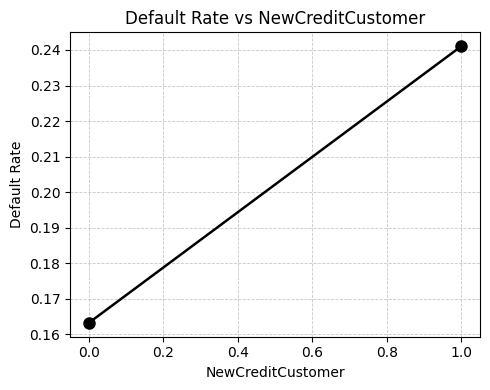

count    34078.000000
mean       956.218088
std         98.173804
min        500.000000
25%       1000.000000
50%       1000.000000
75%       1000.000000
max       1000.000000
Name: CreditScoreEeMini, dtype: float64
               bin  mean_value  default_rate
0   (499.5, 550.0]       500.0      0.437500
1   (550.0, 600.0]       600.0      0.363463
2   (650.0, 700.0]       700.0      0.260628
3   (750.0, 800.0]       800.0      0.255564
4   (850.0, 900.0]       900.0      0.253181
5  (950.0, 1000.0]      1000.0      0.173092


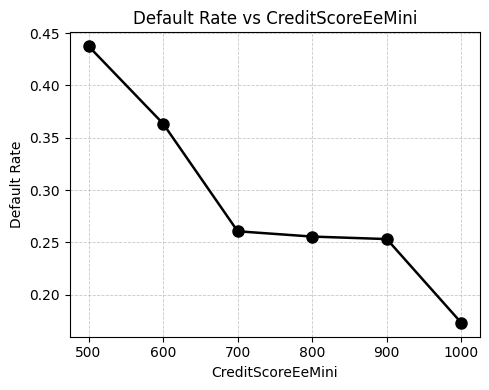

In [22]:
# plot variables vs dr

variable_vs_dr("NewCreditCustomer", X_trai, y_trai)
variable_vs_dr("CreditScoreEeMini", X_trai, y_trai)

In [23]:
# create univariate models to check P>|z|

X_sm = sm.add_constant(X_trai['NewCreditCustomer'])
model_sm = sm.Logit(y_trai, X_sm).fit()
print(model_sm.summary())
print(model_sm.pvalues)

X_sm = sm.add_constant(X_trai['CreditScoreEeMini'])
model_sm = sm.Logit(y_trai, X_sm).fit()
print(model_sm.summary())
print(model_sm.pvalues)

X_sm = sm.add_constant(X_trai['ApplicationSignedHour'])
model_sm = sm.Logit(y_trai, X_sm).fit()
print(model_sm.summary())
print(model_sm.pvalues)

Optimization terminated successfully.
         Current function value: 0.486716
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              default12   No. Observations:                34078
Model:                          Logit   Df Residuals:                    34076
Method:                           MLE   Df Model:                            1
Date:                Mon, 14 Sep 2026   Pseudo R-squ.:                0.009238
Time:                        20:24:25   Log-Likelihood:                -16586.
converged:                       True   LL-Null:                       -16741.
Covariance Type:            nonrobust   LLR p-value:                 3.068e-69
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.6345      0.019    -87.169      0.000      -1.671      -1.598
NewCredi

#### calibration / threshold / default capture

In [24]:
# chooce predictions from model LR or GB to continue

y_pred_trai = y_pred_trai_lr
y_pred_test = y_pred_test_lr

In [25]:
# re-calibrate (intercept-only) on test set
#(I want to align to actual portfolio DR)

y_pred_test_calibrated, delta = intercept_recalibration(y_test, y_pred_test)

print("Intercept shift (delta):", delta)
print("Old mean PD:", np.mean(y_pred_test))
print("New mean PD:", np.mean(y_pred_test_calibrated))
print("Observed DR:", np.mean(y_test))

Intercept shift (delta): -0.38330530029264454
Old mean PD: 0.20317308137827506
New mean PD: 0.1499553083496764
Observed DR: 0.1480617594847872


In [26]:
# re-calibrate (intercept-only) on test set
#(I want to align to actual portfolio DR)

y_pred_test_calibrated_gb, delta_gb = intercept_recalibration(y_test, y_pred_test_gb)

print("Intercept shift (delta):", delta_gb)
print("Old mean PD:", np.mean(y_pred_test_gb))
print("New mean PD:", np.mean(y_pred_test_calibrated_gb))
print("Observed DR:", np.mean(y_test))

Intercept shift (delta): -0.28456611461537196
Old mean PD: 0.18765524
New mean PD: 0.14884146812962304
Observed DR: 0.1480617594847872


prob_bin,Count,Defaults,Avg_PD,Observed_Default_Rate,CI_std,CI_lower,CI_upper,Share_of_Portfolio
"(0, 0.1]",11197,801,0.078,0.072,0.002,0.067,0.076,0.231
"(0.1, 0.2]",28175,4013,0.144,0.142,0.002,0.138,0.147,0.582
"(0.2, 0.3]",7312,1794,0.236,0.245,0.005,0.235,0.255,0.151
"(0.3, 0.4]",1549,480,0.337,0.310,0.012,0.287,0.333,0.032
"(0.4, 0.5]",193,74,0.432,0.383,0.035,0.315,0.452,0.004
"(0.5, 0.6]",20,11,0.532,0.550,0.111,0.332,0.768,0.000
"(0.6, 0.7]",0,0,nan,nan,nan,nan,nan,0
"(0.7, 0.8]",0,0,nan,nan,nan,nan,nan,0


----------------------------------------


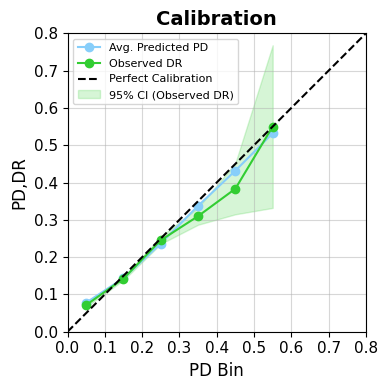

----------------------------------------


In [27]:
# CALIBRATION TABLE AND PLOT

my_calibration(y_test, 
               y_pred_test_calibrated,
               dataset_name="", 
               show_cal_table=True,
               plot_title="Calibration",
               bins = [0, 0.10, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8])

t=0.05, approved=  738, total=48446, approval rate=0.0152, default rate=0.0325
t=0.08, approved= 5400, total=48446, approval rate=0.1115, default rate=0.0602
t=0.10, approved=11197, total=48446, approval rate=0.2311, default rate=0.0715
t=0.15, approved=28093, total=48446, approval rate=0.5799, default rate=0.1009
t=0.20, approved=39372, total=48446, approval rate=0.8127, default rate=0.1223
t=0.25, approved=44499, total=48446, approval rate=0.9185, default rate=0.1351
t=1.00, approved=48446, total=48446, approval rate=1.0000, default rate=0.1481


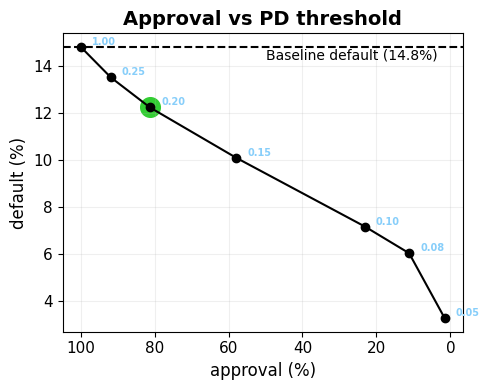

In [28]:
# PD THRESHOLD INVESTIGATION

thresholds = [0.05,0.08,0.10,0.15,0.20,0.25,1.00]
approval = show_approval_vs_default_on_thresholds(y_test, y_pred_test_calibrated, thresholds, title="Approval vs PD threshold", invert=True)

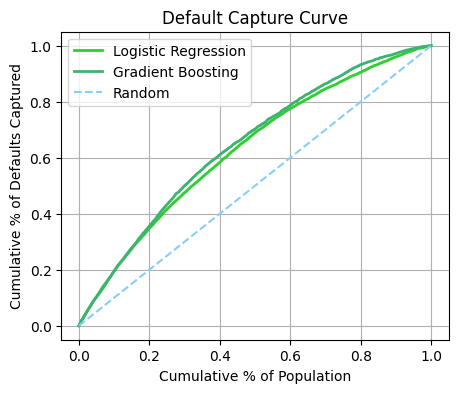

In [29]:
# DEFAULT CAPTURE CURVE

models = {
    "Logistic Regression": y_pred_test_calibrated,
    "Gradient Boosting":   y_pred_test_calibrated_gb,
}

default_capture_curve(y_test, models)

## Business-impact

#### portfolio share and default rate per PD bin: without/with PD threshold


--- accepted:
Total observations: 48446
Accepted BEFORE: 48446
Accepted AFTER: 39372
Approval rate AFTER: 81.27%
Default rate AFTER: 12.23%

--- final table


prob_bin,count,defaults,share_before,default_rate_before,share_after,default_rate_after
"(0, 0.05]",738,24,0.015,0.033,0.019,0.033
"(0.05, 0.1]",10459,777,0.216,0.074,0.266,0.074
"(0.1, 0.15]",16896,2033,0.349,0.120,0.429,0.120
"(0.15, 0.2]",11279,1980,0.233,0.176,0.286,0.176
"(0.2, 0.3]",7312,1794,0.151,0.245,0,0
"(0.3, 0.4]",1549,480,0.032,0.310,0,0
"(0.4, 0.5]",193,74,0.004,0.383,0,0
"(0.5, 0.6]",20,11,0.000,0.550,0,0


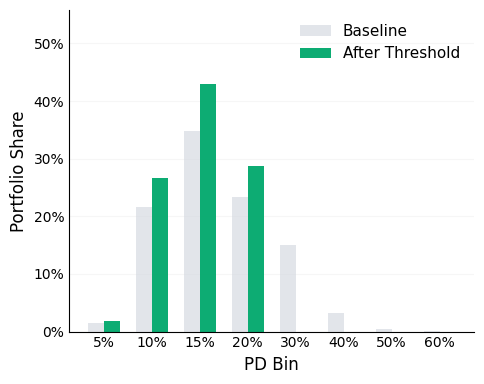

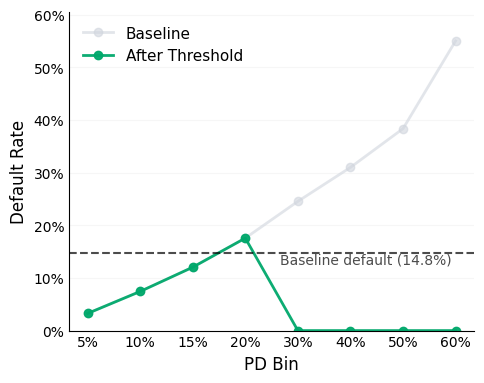

prob_bin,count,defaults,share_before,default_rate_before,share_after,default_rate_after,default_contribution
"(0, 0.05]",738,24,0.015,0.033,0.019,0.033,0.000
"(0.05, 0.1]",10459,777,0.216,0.074,0.266,0.074,0.016
"(0.1, 0.15]",16896,2033,0.349,0.120,0.429,0.120,0.042
"(0.15, 0.2]",11279,1980,0.233,0.176,0.286,0.176,0.041
"(0.2, 0.3]",7312,1794,0.151,0.245,0,0,0.037
"(0.3, 0.4]",1549,480,0.032,0.310,0,0,0.010
"(0.4, 0.5]",193,74,0.004,0.383,0,0,0.002
"(0.5, 0.6]",20,11,0.000,0.550,0,0,0.000


In [30]:
# impact

my_impact(y_test, y_pred_test_calibrated, 0.20)